In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import seaborn as sns

In [28]:
# 1. CARGA DE DATOS
df = pd.read_csv('Playas_canarias.csv')

# 2. Filtramos para excluir Alegranza y La Graciosa
# Usamos el operador ~ para negar la condición (que NO estén en la lista)
islas_a_excluir = ['Alegranza', 'La Graciosa']
df = df[~df['Isla'].isin(islas_a_excluir)]

# 2. LIMPIEZA Y TRANSFORMACIÓN (Creación de "Hechos" numéricos)
def clean_numeric(val):
    if pd.isna(val) or str(val).strip() == '' or str(val).strip() == ',': return 0.0
    # Limpiamos unidades y formatos de número (comas por puntos)
    clean_val = str(val).replace(' metros', '').replace(' km.', '').replace(' km', '').replace(',', '.').strip()
    try:
        return float(clean_val)
    except ValueError:
        return 0.0

In [29]:
# Creamos las versiones numéricas de las variables físicas
# Usamos nombres descriptivos para evitar el KeyError
df['Longitud_num'] = df['Longitud'].apply(clean_numeric)
df['Anchura_num'] = df['Anchura'].apply(clean_numeric)
df['Distancia_Hosp_num'] = df['Distancia1'].apply(clean_numeric)

# Mapeo de variables cualitativas a escala 0-1
# Justificación: Normalizamos para que todas las variables sean comparables estadísticamente
map_mar = {
    'Aguas tranquilas': 0.0,
    
    # Intermedio entre tranquilo y moderado
    'Aguas tranquilas / Oleaje moderado': 0.25,
    'Ventosa / Aguas tranquilas': 0.25,
    'Aguas tranquilas / Ventosa': 0.25,
    
    'Oleaje moderado': 0.5,
    
    # Intermedio entre moderado y fuerte
    'Oleaje moderado / Oleaje fuerte': 0.75,
    'Oleaje moderado / Ventosa': 0.75,
    'Ventosa / Oleaje moderado': 0.75,
    
    'Oleaje fuerte': 1.0,
    'Oleaje fuerte / Ventosa': 1.0
}
map_nivel = {'Bajo': 0.0, 'Medio': 0.5, 'Alto': 1.0}
map_urb = {'Aislada': 0.0, 'Semiurbana': 0.5, 'Urbana': 1.0}
map_bin = {'Sí': 1.0, 'No': 0.0}

df['Fact_Paseo'] = df['Paseo_mar'].map(map_bin).fillna(0.0)
df['Fact_Mar'] = df['Condicione'].map(map_mar).fillna(0.5)
df['Fact_Ocup'] = df['Grado_ocup'].map(map_nivel).fillna(0.5)
df['Fact_Urb'] = df['Grado_urba'].map(map_urb).fillna(0.5)
df['Fact_Bandera'] = df['Bandera_az'].map(map_bin).fillna(0.0)
df['Fact_Auxilio'] = df['Auxilio_y_'].map(map_bin).fillna(0.0)
df['Fact_Nudismo'] = df['Nudismo'].map(map_bin).fillna(0.0)
df['Fact_Es_Arena'] = df['Composici'].apply(lambda x: 1.0 if 'Arena' in str(x) else 0.0)
df['Fact_Dificultad_Acceso'] = df['Forma_de_a'].apply(lambda x: 1.0 if 'difícil' in str(x) or 'Barco' in str(x) or 'Coche' in str(x) else 0.0)

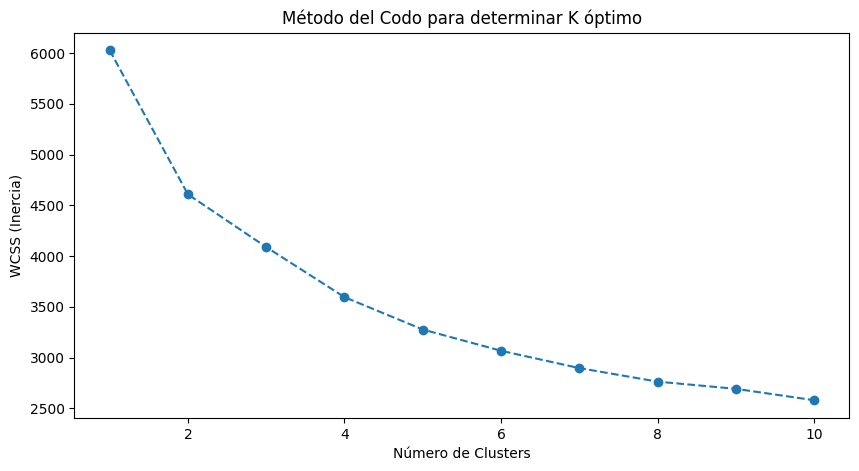

In [20]:
# 3. ANÁLISIS EXPLORATORIO: MÉTODO DEL CODO
# Seleccionamos variables que definen el perfil real de la playa
features_cluster = ['Fact_Ocup', 'Fact_Urb', 'Fact_Mar', 'Fact_Bandera', 'Fact_Auxilio', 'Fact_Nudismo', 'Fact_Es_Arena',
                    'Fact_Paseo', 'Longitud_num', 'Anchura_num', 'Distancia_Hosp_num']
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df[features_cluster])

wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

# Generar gráfico del codo
plt.figure(figsize=(10, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Método del Codo para determinar K óptimo')
plt.xlabel('Número de Clusters')
plt.ylabel('WCSS (Inercia)')
plt.show()

In [21]:
kmeans_final = KMeans(n_clusters=4, random_state=42, n_init=10)
df['Cluster_ID'] = kmeans_final.fit_predict(scaled_data)

In [ ]:
# 4. CÁLCULO DE INDICADORES (Pesos justificados según el MITECO y feedback)
# Maximizamos para normalizar distancias
max_hosp = df['Distancia_Hosp_num'].max() if df['Distancia_Hosp_num'].max() > 0 else 1
max_long = df['Longitud_num'].max() if df['Longitud_num'].max() > 0 else 1
max_anch = df['Anchura_num'].max() if df['Anchura_num'].max() > 0 else 1

# Iseguridad (1 = Playa más segura; 0 = Peligrosa)
# Justificación: El oleaje es el mayor riesgo (40%) y el socorrismo el mayor alivio (30%) [2, 3]
df['Iseguridad'] = (
    0.30 * (1 - df['Fact_Mar']) + 
    0.30 * df['Fact_Auxilio'] + 
    0.05 * (1 - (df['Distancia_Hosp_num'] / max_hosp)) + 
    0.2 * (1 - df['Fact_Dificultad_Acceso']) +
    0.05 * df['Fact_Urb']+ 
    0.05 * (1 - df['Longitud_num'] / max_long) + 
    0.05 * (1 - df['Anchura_num'] / max_anch)
)

# Iparadisíaca (1 = Paraíso total; 0 = No paradisíaca)
# Justificación: Premiamos la baja ocupación y el entorno virgen [3, 4]
df['Iparadisíaca'] = (
    0.30 * (1 - df['Fact_Ocup']) + 
    0.15 * (1 - df['Fact_Mar']) + 
    0.25 * (1 - df['Fact_Urb']) + 
    0.10 * df['Fact_Bandera'] + 
    0.10 * df['Fact_Es_Arena'] + 
    0.05 * (df['Longitud_num'] / max_long) + 
    0.05 * (df['Anchura_num'] / max_anch)
)


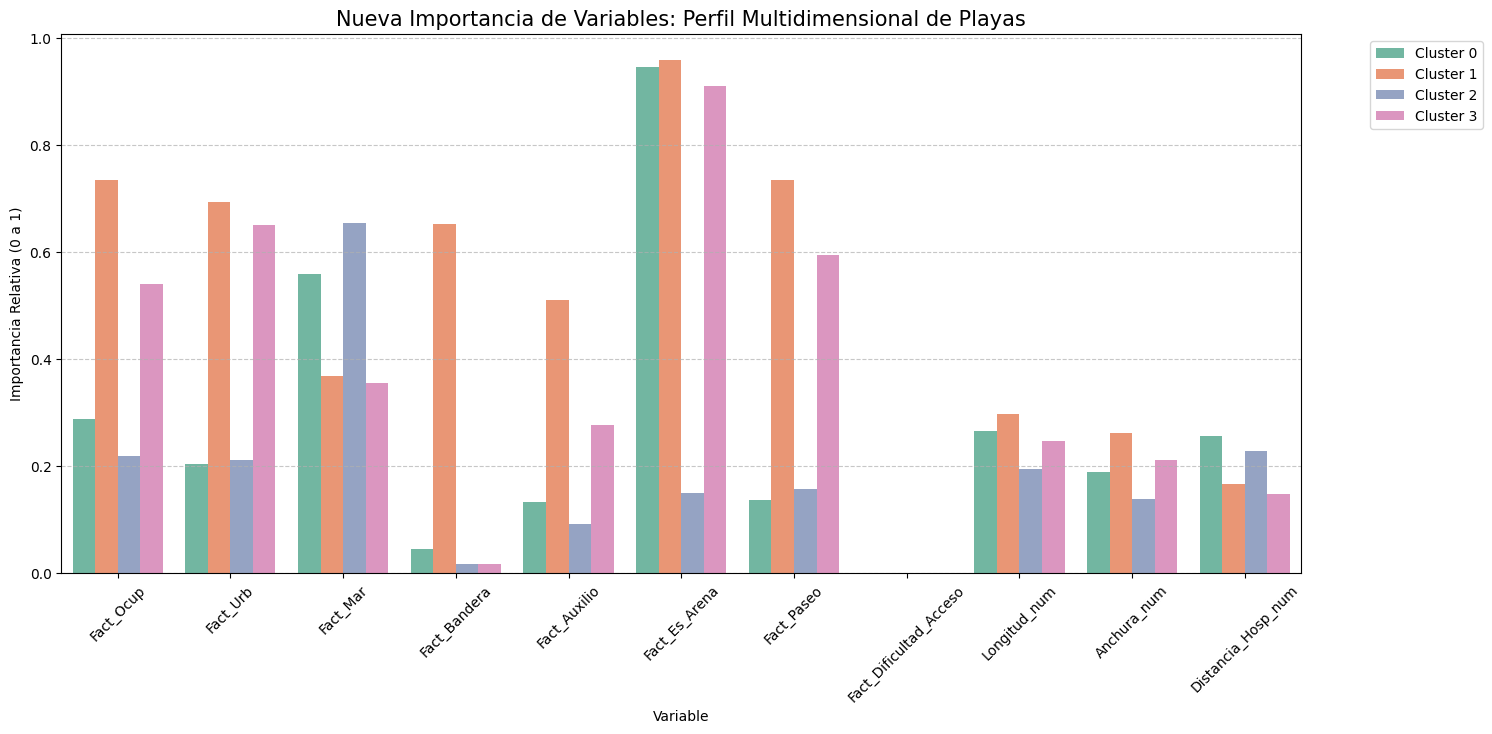

In [23]:
features_cluster = [
    'Fact_Ocup', 'Fact_Urb', 'Fact_Mar', 'Fact_Bandera', 'Fact_Auxilio', 
    'Fact_Es_Arena', 'Fact_Paseo', 'Fact_Dificultad_Acceso', 'Longitud_num', 'Anchura_num', 'Distancia_Hosp_num'
]

# 2. ESCALAMOS TODAS PARA EL GRÁFICO (0 a 1)
# Esto es vital para que la importancia sea comparable visualmente
from sklearn.preprocessing import MinMaxScaler
scaler_plot = MinMaxScaler()
df_norm = pd.DataFrame(scaler_plot.fit_transform(df[features_cluster]), columns=features_cluster)
df_norm['Cluster_ID'] = df['Cluster_ID']

# 3. CALCULAMOS LOS CENTROIDES (Importancia real)
centroides_all = df_norm.groupby('Cluster_ID').mean()
centroides_all['Perfil'] = [f'Cluster {i}' for i in range(4)]

# 4. GRÁFICA DE IMPORTANCIA TOTAL
plt.figure(figsize=(16, 7))
centroides_melted = centroides_all.melt(id_vars='Perfil', var_name='Variable', value_name='Peso')
sns.barplot(data=centroides_melted, x='Variable', y='Peso', hue='Perfil', palette='Set2')

plt.title('Nueva Importancia de Variables: Perfil Multidimensional de Playas', fontsize=15)
plt.ylabel('Importancia Relativa (0 a 1)')
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

- **Cluster 2 (Urbanas Premium)**: Es el grupo de excelencia. Se distingue por ser el único con una presencia significativa de Bandera Azul, los niveles más altos de socorrismo y accesibilidad para personas con discapacidad. Son playas extensas en longitud y anchura, situadas en entornos muy urbanizados con paseo marítimo y corta distancia a hospitales.

- **Cluster 0 (Urbanas Estándar)**: Agrupa playas integradas en núcleos urbanos con paseo marítimo y composición de arena, pero que carecen de la certificación de Bandera Azul y presentan una infraestructura de servicios menos completa que el grupo premium.

- **Cluster 1 (Aisladas Naturales)**: Identifica grandes extensiones de arena situadas en entornos vírgenes. Se caracterizan por su difícil acceso, baja ocupación y por encontrarse a la mayor distancia de los centros hospitalarios, lo que las define como paraísos tranquilos pero con menor cobertura sanitaria.

- **Cluster 3 (Salvajes y Rocosas)**: Este grupo presenta el oleaje más fuerte del archipiélago y una composición mayoritaria de roca o grava. Al ser playas aisladas y sin servicios de auxilio, representan el foco de mayor riesgo para el bañista y un escenario ideal para rodajes que busquen una estética indómita.


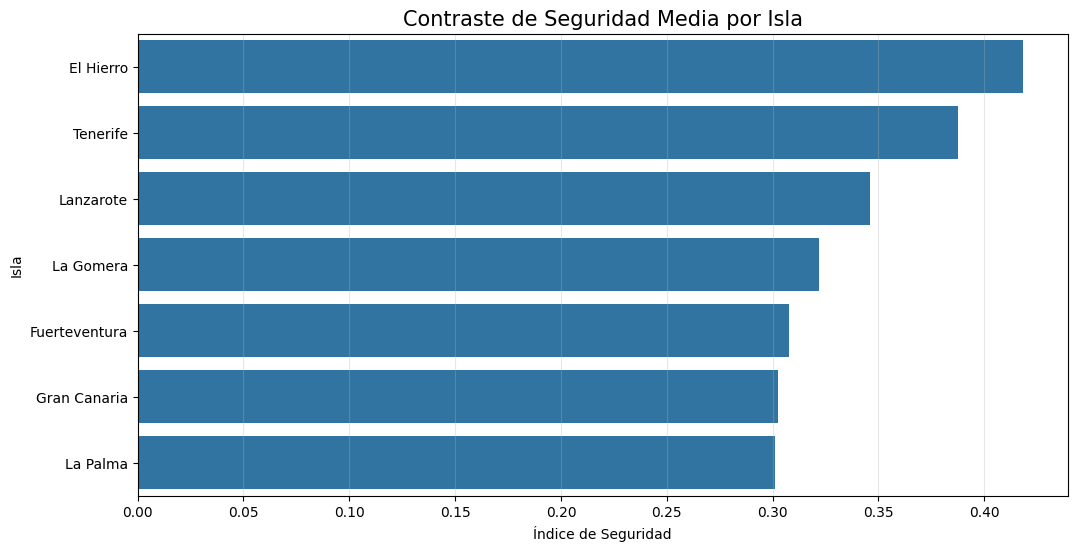

In [24]:
# 1. CÁLCULO DINÁMICO DE MEDIAS POR ISLA
# Agrupamos por Isla y calculamos la media de tus indicadores compuestos
df_islas = df.groupby('Isla')[['Iseguridad', 'Iparadisíaca']].mean().sort_values(by='Iseguridad', ascending=False).reset_index()

# 2. VISUALIZACIÓN DEL CONTRASTE DE SEGURIDAD (Acto 1)
plt.figure(figsize=(12, 6))
sns.barplot(data=df_islas, x='Iseguridad', y='Isla')

plt.title('Contraste de Seguridad Media por Isla', fontsize=15)
plt.xlabel('Índice de Seguridad')
plt.ylabel('Isla')
plt.grid(axis='x', alpha=0.3)
plt.show()

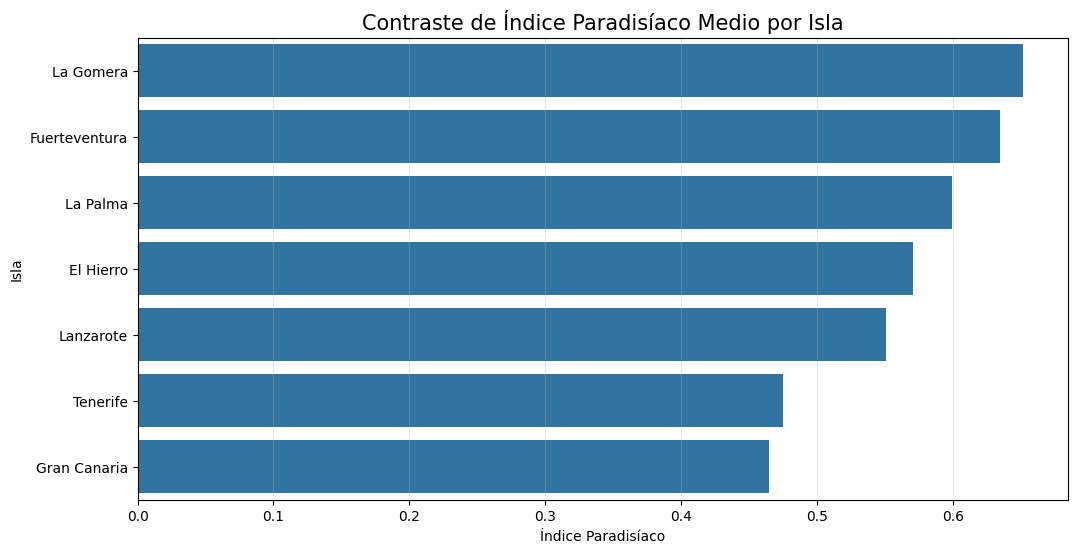

In [25]:
# 1. CÁLCULO DE MEDIAS POR ISLA (Ordenado por Índice Paradisíaco)
# Agrupamos y ordenamos descendientemente para ver qué islas son las más "paradisíacas"
df_islas_paraíso = df.groupby('Isla')[['Iseguridad', 'Iparadisíaca']].mean().sort_values(by='Iparadisíaca', ascending=False).reset_index()

# 2. VISUALIZACIÓN DEL CONTRASTE PARADISÍACO (Acto 2)
plt.figure(figsize=(12, 6))
sns.barplot(data=df_islas_paraíso, x='Iparadisíaca', y='Isla')
plt.title('Contraste de Índice Paradisíaco Medio por Isla', fontsize=15)
plt.xlabel('Índice Paradisíaco')
plt.ylabel('Isla')
plt.grid(axis='x', alpha=0.3)
plt.show()

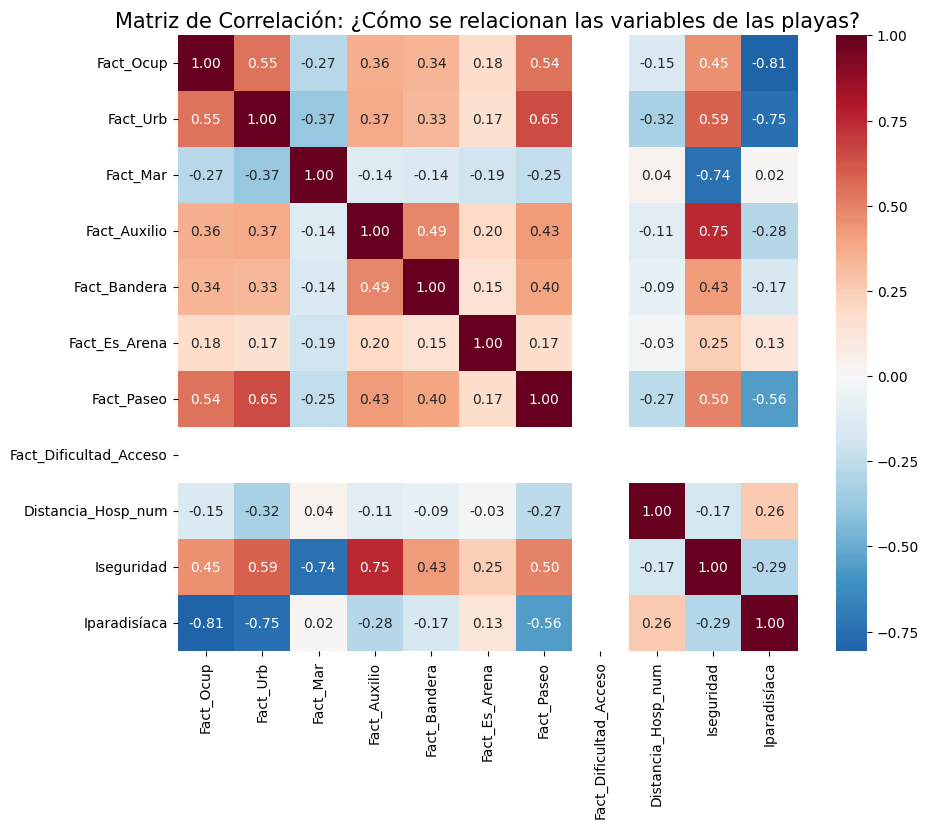

In [26]:
# 1. SELECCIÓN DE VARIABLES PARA CORRELACIÓN
# Incluimos los indicadores y los hechos transformados
cols_analisis = [
    'Fact_Ocup', 'Fact_Urb', 'Fact_Mar', 'Fact_Auxilio', 'Fact_Bandera', 
    'Fact_Es_Arena', 'Fact_Paseo', 'Fact_Dificultad_Acceso', 'Distancia_Hosp_num',
    'Iseguridad', 'Iparadisíaca'
]

# Calcular la matriz
corr_matrix = df[cols_analisis].corr()

# Visualización del Mapa de Calor
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, fmt=".2f")
plt.title('Matriz de Correlación: ¿Cómo se relacionan las variables de las playas?', fontsize=15)
plt.show()

In [27]:
df.to_csv('Playas_canarias_limpio.csv', index=False)
print("Archivo 'Playas_canarias_limpio.csv' guardado con éxito.")

Archivo 'Playas_canarias_limpio.csv' guardado con éxito.
